# Install dependencies 
in bash terminal, do:

python -m pip install pandas seaborn matplotlib scikit-learn pydotplus ipykernel

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pydotplus

from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from IPython.display import Image
from itertools import product
from sklearn.metrics import f1_score

In [2]:
dataset = pd.read_csv('../dataset/datasets/full_v5_pca.csv')
dataset.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC80,PC81,PC82,PC83,PC84,PC85,PC86,Activity,subject,split
0,-2.510640,0.065206,1.422804,0.509251,-0.369177,0.989867,-1.170883,0.291671,-0.431837,1.131533,...,-0.288790,-0.072087,0.121385,-0.062924,-0.327626,-0.119718,0.385517,STANDING,1,train
1,-2.246651,0.288100,1.504931,-1.176082,-1.089556,0.067572,-0.720293,-0.199577,-0.191529,0.024785,...,-0.105266,0.070398,0.108667,-0.022140,-0.076109,0.229156,0.171370,STANDING,1,train
2,-2.058132,-0.144074,1.630807,0.041294,-0.224343,0.074839,-0.337597,-0.091450,-0.517965,0.080929,...,-0.001238,-0.018007,0.170947,0.069512,0.165213,-0.080980,0.039015,STANDING,1,train
3,-2.425624,-0.564929,1.288230,-1.490013,0.656977,0.105036,-0.605237,0.152080,-0.170998,-0.413299,...,0.173628,0.127832,-0.098609,-0.052313,0.233912,-0.091912,-0.257863,STANDING,1,train
4,-2.405799,-0.634873,1.591285,-0.643972,0.690523,-0.201769,-0.480024,0.124156,0.189342,0.087238,...,0.283797,0.177771,0.169884,0.014688,0.164031,-0.005736,0.100048,STANDING,1,train


In [3]:
from sklearn.preprocessing import LabelEncoder

split = dataset["split"].astype("string").str.lower()
expected_splits = {"train", "test"}
unknown_splits = set(split.dropna().unique()) - expected_splits
if unknown_splits:
    raise ValueError(f"Unexpected values in 'split': {sorted(unknown_splits)}")

# The split column controls the evaluation partition; it is not a model feature.
X = dataset.drop(columns=["Activity", "subject", "split"])
y_text = dataset["Activity"]
groups = dataset["subject"]

le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y_text),
    index=y_text.index,
    name="Activity"
)

print("Encoded mapping:")
for encoded_value, activity in enumerate(le.classes_):
    print(encoded_value, "=", activity)

Encoded mapping:
0 = LAYING
1 = SITTING
2 = STANDING
3 = WALKING
4 = WALKING_DOWNSTAIRS
5 = WALKING_UPSTAIRS


In [4]:
train_mask = split.eq("train")
test_mask = split.eq("test")

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
groups_train, groups_test = groups.loc[train_mask], groups.loc[test_mask]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)
print("Number of overlapping subjects:", len(overlap))
print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))

Subjects in training data:
[np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Subjects in test data:
[np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)]

Number of training subjects: 21
Number of test subjects: 9

Overlapping subjects: set()
Number of overlapping subjects: 0

Training rows: 7177
Test rows: 3122


In [5]:
# Train/test variables are prepared in the previous cell from the dataset's split column.

In [6]:
# Five-fold subject-aware cross-validation for hyperparameter tuning. The final test set remains untouched.
cv = GroupKFold(n_splits=5)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5, 10],
}

param_keys = list(param_grid)
param_combinations = [
    dict(zip(param_keys, values))
    for values in product(*param_grid.values())
]

best_score = -1.0
best_params = None
print(f"Testing {len(param_combinations)} hyperparameter combinations across 5 folds...")

for params in param_combinations:
    fold_scores = []

    for fold, (train_idx, validation_idx) in enumerate(
        cv.split(X_train, y_train, groups=groups_train),
        start=1,
    ):
        candidate = DecisionTreeClassifier(random_state=69, **params)
        candidate.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        validation_pred = candidate.predict(X_train.iloc[validation_idx])
        fold_score = f1_score(
            y_train.iloc[validation_idx],
            validation_pred,
            average="macro",
            zero_division=0,
        )
        fold_scores.append(fold_score)

    mean_validation_score = sum(fold_scores) / len(fold_scores)
    print(
        f"{params} -> 5-fold validation macro-F1: "
        f"{mean_validation_score:.4f} "
        f"(folds: {[round(score, 4) for score in fold_scores]})"
    )

    if mean_validation_score > best_score:
        best_score = mean_validation_score
        best_params = params

print("Best 5-fold validation macro-F1:", best_score)
print("Best parameters:", best_params)

# Refit the selected configuration on all training rows before final testing.
model = DecisionTreeClassifier(random_state=69, **best_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate metrics and the normalized matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

labels = list(range(len(le.classes_)))
cm_percent = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"
)


Testing 24 hyperparameter combinations across 5 folds...
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1} -> 5-fold validation macro-F1: 0.7337 (folds: [0.7501, 0.6869, 0.7287, 0.7409, 0.7621])
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 5} -> 5-fold validation macro-F1: 0.7438 (folds: [0.7584, 0.6912, 0.7462, 0.749, 0.7742])
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 10} -> 5-fold validation macro-F1: 0.7487 (folds: [0.7634, 0.7125, 0.7489, 0.7621, 0.7565])
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1} -> 5-fold validation macro-F1: 0.7323 (folds: [0.7497, 0.6887, 0.7365, 0.728, 0.7584])
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 5} -> 5-fold validation macro-F1: 0.7438 (folds: [0.7584, 0.6912, 0.7462, 0.749, 0.7742])
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 1

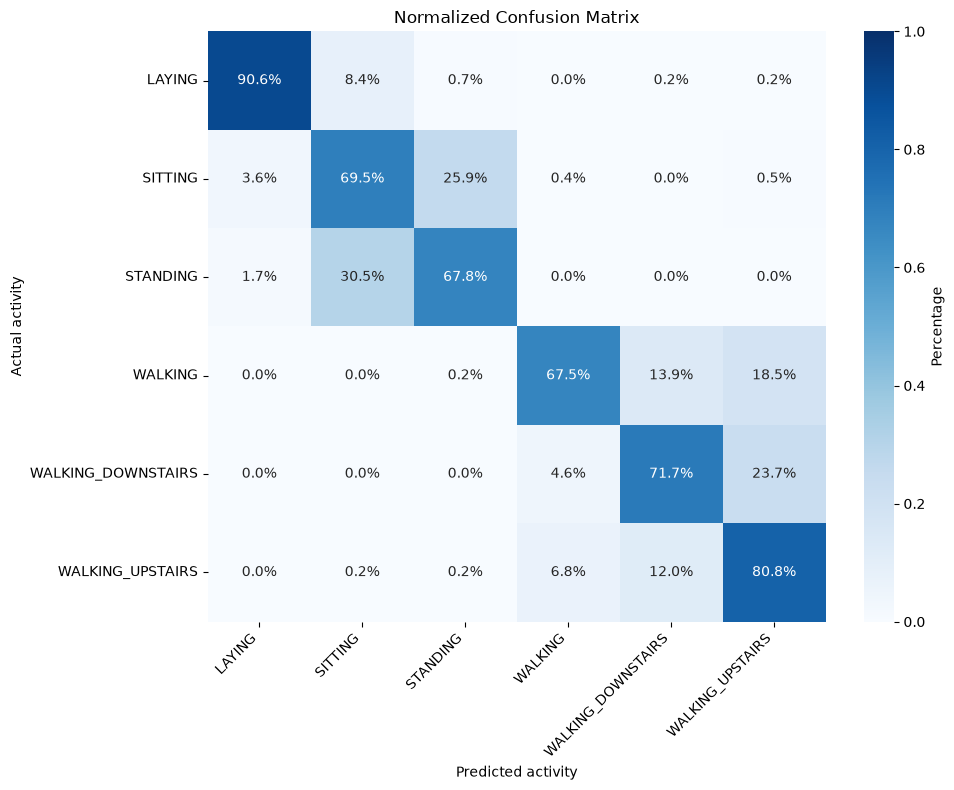

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={"label": "Percentage"}
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted activity")
plt.ylabel("Actual activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
y_test_names = le.inverse_transform(y_test)
y_pred_names = le.inverse_transform(y_pred)

print(y_pred_names[:10])

['STANDING' 'STANDING' 'SITTING' 'SITTING' 'STANDING' 'STANDING' 'LAYING'
 'STANDING' 'STANDING' 'STANDING']


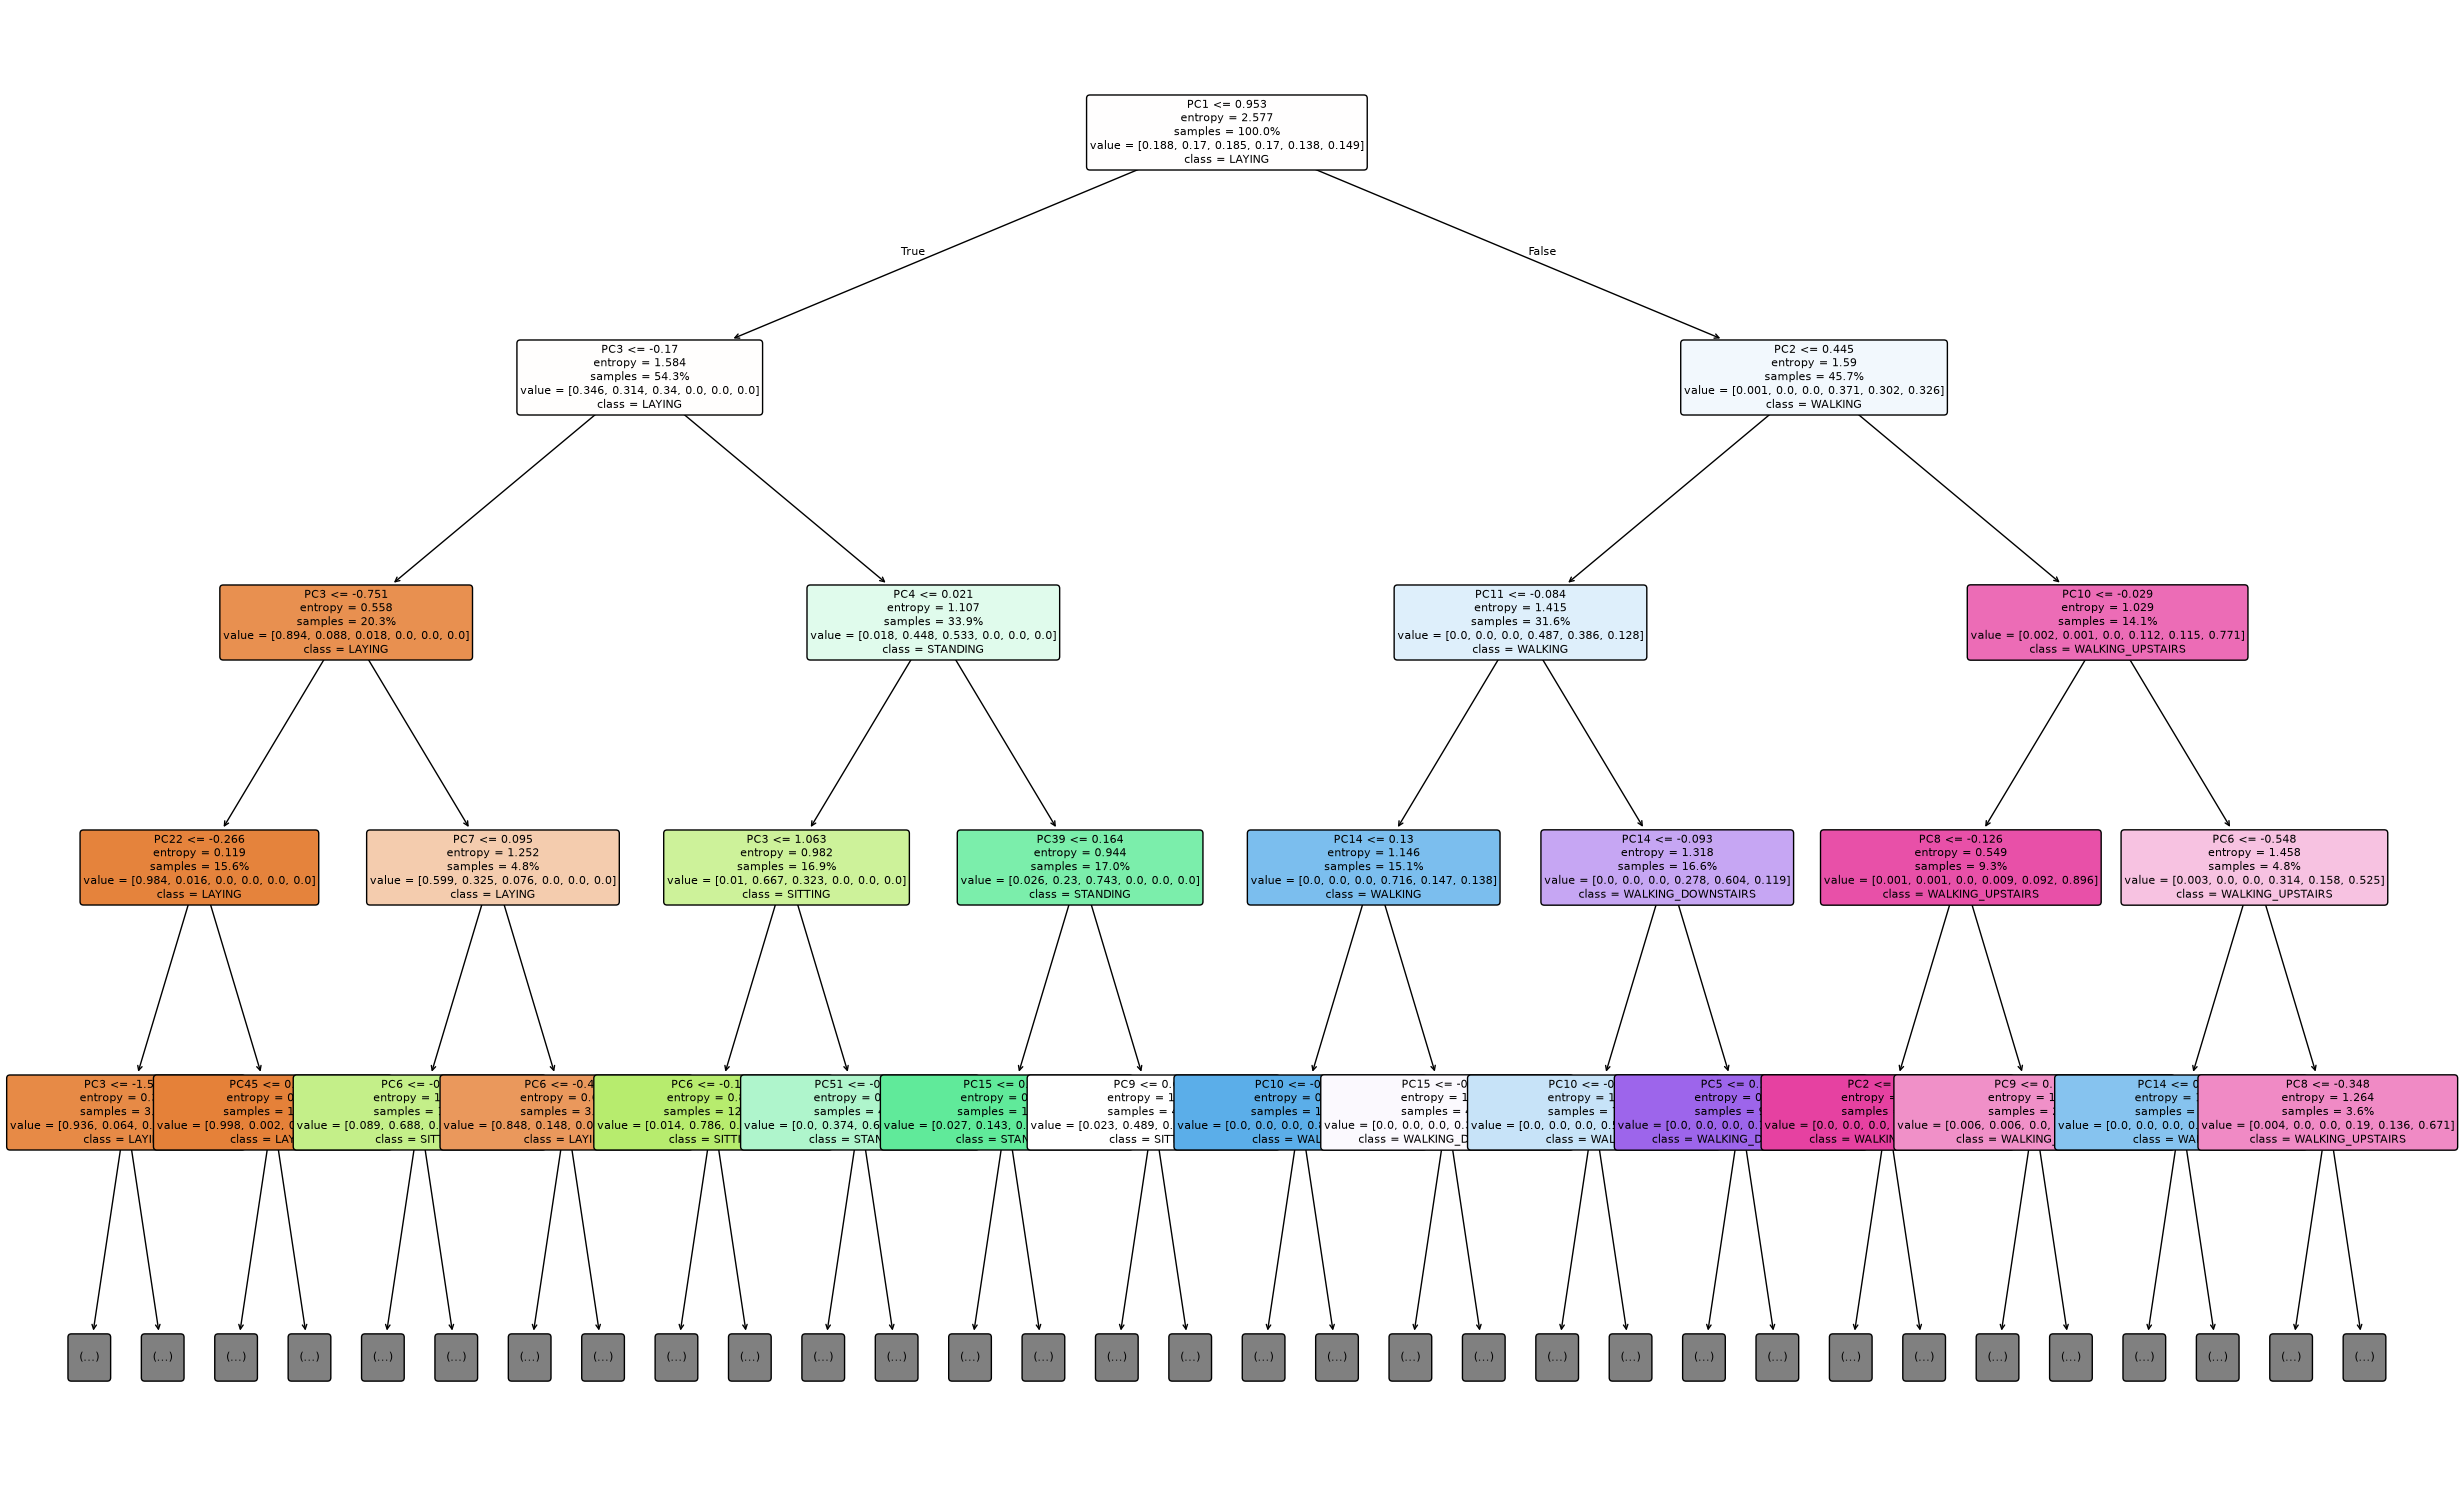

In [9]:
plt.figure(figsize=(25, 15))

tree.plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=le.classes_.astype(str).tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
    max_depth=4  # Prevents rendering 69 PCA components into an illegible graph
)

plt.tight_layout()
plt.show()

In [10]:
model_name = "cart_v7 Tuned Decision Tree"
dataset_name = "full_v5_pca"
note = "N/A"

report = classification_report(
    y_test,
    y_pred,
    labels=list(range(len(le.classes_))),
    target_names=le.classes_,
    output_dict=True,
    zero_division=0,
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=list(range(len(le.classes_))),
    normalize="true",
).round(4).tolist()

record = {
    "timestamp": datetime.now().isoformat(),
    "dataset": dataset_name,
    "model": model_name,
    "note": note or "N/A",
    "overall_accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "classes": le.classes_.tolist(),
    "confusion_matrix_percent": cm_normalized,
    "classification_report": report,
    "params": {
        "learning_rate": None,
        "max_depth": model.get_params().get("max_depth"),
        "n_estimators": None,
        "num_round": None,
        "subsample": None,
        "colsample_bytree": None,
        "min_child_weight": None,
        "criterion": model.get_params().get("criterion"),
        "min_samples_split": model.get_params().get("min_samples_split"),
        "min_samples_leaf": model.get_params().get("min_samples_leaf"),
        "random_state": model.get_params().get("random_state"),
    },
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(record) + "\n")

print(
    f"Logged {record['model']} on dataset "
    f"'{record['dataset']}' to results.jsonl"
)

Logged cart_v7 Tuned Decision Tree on dataset 'full_v5_pca' to results.jsonl
